# Building the Financial Spending Assessment Model

**Main research question**

How does explainability, specifically SHAP-based feature attribution and LLM-generated plain language explanations, impact user understanding of, trust in, and confidence in AI-assisted financial spending assessments?

**Purpose of this notebook**

This notebook covers the foundation stage of the project. At this point, the goal is to build a defensible model for `EXPENSHILO` that is accurate enough to be credible and interpretable enough to support later SHAP explanations, plain-language explanations, the UI, and the respondent study.

At this stage, we are not yet measuring user trust or understanding directly. We are creating the model and analytical structure that those later stages will depend on.

## Environment and Reproducibility

This section sets up imports, display preferences, plotting defaults, and helper functions. Everything is kept inside the notebook so the workflow remains self-contained.

In [10]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from pandas.api.types import is_numeric_dtype
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, f1_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    import seaborn as sns
    HAS_SEABORN = True
except ModuleNotFoundError:
    sns = None
    HAS_SEABORN = False

try:
    import xgboost as xgb
    HAS_XGBOOST = True
except ModuleNotFoundError:
    xgb = None
    HAS_XGBOOST = False

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20
COLORS = {
    "navy": "#1B2A4A",
    "teal": "#2E8B8B",
    "gold": "#D4930D",
    "red": "#8B2E2E",
}

pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 130,
})

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "backend" / "data" / "SCFP2022.csv"
if not DATA_PATH.exists():
    DATA_PATH = PROJECT_ROOT / "data" / "SCFP2022.csv"


def show_note(text: str) -> None:
    display(Markdown(f"> **Why we proceed:** {text}"))


def display_heading(text: str) -> None:
    display(Markdown(f"**{text}**"))


def plot_grouped_histograms(dataframe: pd.DataFrame, features: list[str], target_col: str = "target") -> None:
    n_cols = 2
    n_rows = int(np.ceil(len(features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, feature in zip(axes, features):
        for target_value, color, label in [(0, COLORS["navy"], "Not overspending"), (1, COLORS["gold"], "Overspending")]:
            subset = dataframe.loc[dataframe[target_col] == target_value, feature].dropna()
            ax.hist(subset, bins=40, density=True, alpha=0.55, color=color, label=label)
        ax.set_title(feature)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)

    for ax in axes[len(features):]:
        ax.axis("off")

    plt.tight_layout()


def plot_grouped_boxplots(dataframe: pd.DataFrame, features: list[str], target_col: str = "target") -> None:
    n_cols = 2
    n_rows = int(np.ceil(len(features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, feature in zip(axes, features):
        data_0 = dataframe.loc[dataframe[target_col] == 0, feature].dropna()
        data_1 = dataframe.loc[dataframe[target_col] == 1, feature].dropna()
        ax.boxplot([data_0, data_1], labels=["Not overspending", "Overspending"], patch_artist=True)
        ax.set_title(feature)
        ax.grid(alpha=0.2)

    for ax in axes[len(features):]:
        ax.axis("off")

    plt.tight_layout()


def compute_univariate_auc(series: pd.Series, target: pd.Series) -> float:
    values = series.replace([np.inf, -np.inf], np.nan)
    if values.isna().all():
        return np.nan
    filled = values.fillna(values.median())
    auc = roc_auc_score(target, filled)
    return max(auc, 1 - auc)


def screen_feature_pool(dataframe: pd.DataFrame, target_col: str, blocked_features: set[str], keyword_allowlist: list[str], blocked_name_fragments: list[str], max_missing: float = 0.40) -> pd.DataFrame:
    rows = []
    target = dataframe[target_col]

    for feature in dataframe.columns:
        upper_name = feature.upper()
        if feature in blocked_features:
            continue
        if any(fragment in upper_name for fragment in blocked_name_fragments):
            continue
        if upper_name.startswith("H") and feature not in {"HOUSECL"}:
            continue
        if feature == target_col:
            continue

        series = dataframe[feature]
        if not is_numeric_dtype(series):
            continue

        nunique = int(series.nunique(dropna=True))
        missing_pct = float(series.isna().mean())
        if nunique <= 1 or missing_pct > max_missing:
            continue
        if not any(keyword in upper_name for keyword in keyword_allowlist):
            continue

        try:
            auc = compute_univariate_auc(series, target)
        except Exception:
            continue

        rows.append({
            "feature": feature,
            "nunique": nunique,
            "missing_pct": missing_pct,
            "univariate_auc": auc,
        })

    results = pd.DataFrame(rows)
    if not results.empty:
        results = results.sort_values(["univariate_auc", "missing_pct"], ascending=[False, True]).reset_index(drop=True)
    return results


def add_engineered_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    engineered_df = dataframe.copy()

    if "DEBT2INC" in engineered_df.columns:
        engineered_df["DTI"] = engineered_df["DEBT2INC"]
    elif {"DEBT", "INCOME"}.issubset(engineered_df.columns):
        engineered_df["DTI"] = np.where(engineered_df["INCOME"] > 0, engineered_df["DEBT"] / engineered_df["INCOME"], np.nan)

    if {"CONSPAY", "INCOME"}.issubset(engineered_df.columns):
        engineered_df["PAYMENT_TO_INC"] = np.where(engineered_df["INCOME"] > 0, (engineered_df["CONSPAY"] * 12) / engineered_df["INCOME"], np.nan)

    if {"CCBAL", "INCOME"}.issubset(engineered_df.columns):
        engineered_df["CC_TO_INC"] = np.where(engineered_df["INCOME"] > 0, engineered_df["CCBAL"] / engineered_df["INCOME"], np.nan)

    if {"FOODHOME", "AGE"}.issubset(engineered_df.columns):
        engineered_df["FOODHOME_X_AGE"] = engineered_df["FOODHOME"] * engineered_df["AGE"]

    if {"DTI", "AGE"}.issubset(engineered_df.columns):
        engineered_df["DTI_X_AGE"] = engineered_df["DTI"] * engineered_df["AGE"]

    if {"LIQ", "DTI"}.issubset(engineered_df.columns):
        engineered_df["LIQ_SQUEEZE"] = engineered_df["LIQ"] * (1 - engineered_df["DTI"].clip(0, 1))

    if {"FOODHOME", "FOODAWAY"}.issubset(engineered_df.columns):
        engineered_df["FOOD_DISCRETIONARY"] = engineered_df["FOODAWAY"] / (engineered_df["FOODHOME"] + engineered_df["FOODAWAY"] + 1)

    return engineered_df


def clean_modeling_frame(dataframe: pd.DataFrame, feature_cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    clean_df = dataframe.copy()
    prep_log = []

    for col in feature_cols:
        inf_count = int(np.isinf(clean_df[col]).sum()) if is_numeric_dtype(clean_df[col]) else 0
        if inf_count > 0:
            clean_df[col] = clean_df[col].replace([np.inf, -np.inf], np.nan)
            prep_log.append({"feature": col, "step": "replace_inf_with_nan", "count": inf_count, "value": np.nan})

    for col in feature_cols:
        if clean_df[col].isna().any():
            na_count = int(clean_df[col].isna().sum())
            median_value = float(clean_df[col].median())
            clean_df[col] = clean_df[col].fillna(median_value)
            prep_log.append({"feature": col, "step": "median_imputation", "count": na_count, "value": median_value})

    discrete_features = {"EDUC", "FAMSTRUCT", "HOUSECL", "FINLIT", "KIDS", "LATE", "CHECKING", "EMERGSAV"}
    continuous_features = [col for col in feature_cols if col not in discrete_features]
    for col in continuous_features:
        upper_bound = float(clean_df[col].quantile(0.99))
        clipped_count = int((clean_df[col] > upper_bound).sum())
        if clipped_count > 0:
            clean_df[col] = clean_df[col].clip(upper=upper_bound)
            prep_log.append({"feature": col, "step": "upper_clip_p99", "count": clipped_count, "value": upper_bound})

    prep_log_df = pd.DataFrame(prep_log)
    return clean_df, prep_log_df


def evaluate_model_suite(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series, groups_train: pd.Series) -> tuple[pd.DataFrame, dict]:
    cv_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
        ]),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
    }

    if HAS_XGBOOST:
        scale_pos_weight = (len(y_train) - int(y_train.sum())) / max(int(y_train.sum()), 1)
        models["XGBoost"] = xgb.XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            scale_pos_weight=scale_pos_weight,
        )

    rows = []
    fitted_models = {}

    for name, estimator in models.items():
        cv_scores = cross_val_score(
            clone(estimator),
            X_train,
            y_train,
            groups=groups_train,
            cv=cv_splitter,
            scoring="roc_auc",
            n_jobs=1,
        )

        fitted_estimator = clone(estimator)
        fitted_estimator.fit(X_train, y_train)
        y_prob = fitted_estimator.predict_proba(X_test)[:, 1]
        y_pred = fitted_estimator.predict(X_test)

        rows.append({
            "model": name,
            "cv_auc_mean": float(np.mean(cv_scores)),
            "cv_auc_std": float(np.std(cv_scores)),
            "test_auc": float(roc_auc_score(y_test, y_prob)),
            "accuracy": float(accuracy_score(y_test, y_pred)),
            "f1": float(f1_score(y_test, y_pred)),
            "brier": float(brier_score_loss(y_test, y_prob)),
        })
        fitted_models[name] = fitted_estimator

    performance_df = pd.DataFrame(rows).sort_values(["cv_auc_mean", "test_auc"], ascending=[False, False]).set_index("model")
    return performance_df, fitted_models


def plot_model_performance(performance_df: pd.DataFrame) -> None:
    plot_df = performance_df.reset_index()
    x = np.arange(len(plot_df))
    width = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar(x - width / 2, plot_df["cv_auc_mean"], width, yerr=plot_df["cv_auc_std"], capsize=4, label="CV AUC", color=COLORS["teal"])
    plt.bar(x + width / 2, plot_df["test_auc"], width, label="Test AUC", color=COLORS["navy"])
    plt.xticks(x, plot_df["model"], rotation=15, ha="right")
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title("Baseline Model Comparison")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()


def summarize_baseline_results(performance_df: pd.DataFrame) -> str:
    best_name = performance_df.index[0]
    best_row = performance_df.iloc[0]
    if len(performance_df) > 1:
        second_name = performance_df.index[1]
        gap = best_row["cv_auc_mean"] - performance_df.iloc[1]["cv_auc_mean"]
        if gap < 0.01:
            return (
                f"{best_name} currently leads by grouped CV AUC, but the margin over {second_name} is small. Because the broader study depends on explainability as well as prediction quality, we should carry the strongest model forward carefully and avoid overclaiming that tiny performance gaps justify much greater complexity."
            )
    return (
        f"{best_name} is the strongest baseline by grouped CV AUC ({best_row['cv_auc_mean']:.3f}). That makes it the current front-runner, but the next stage should still check refinement, calibration, and feature importance before we finalize the model that will feed SHAP and the explanation study."
    )


print(f"Data path: {DATA_PATH}")
print(f"Seaborn available: {HAS_SEABORN}")
print(f"XGBoost available: {HAS_XGBOOST}")

Data path: c:\Users\john_\Desktop\ana_600_capstone\backend\data\SCFP2022.csv
Seaborn available: True
XGBoost available: False


## Load the SCF Data

We begin by loading the SCF 2022 data and checking its size, structure, and a sample of the available variables.

In [11]:
df_raw = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df_raw):,}")
print(f"Columns: {len(df_raw.columns):,}")

display_heading("First 20 columns")
display(pd.DataFrame({"column": df_raw.columns[:20]}))

display_heading("Preview")
display(df_raw.head())

Rows: 22,975
Columns: 357


**First 20 columns**

,column
0,YY1
1,Y1
2,WGT
3,HHSEX
4,AGE
5,AGECL
6,EDUC
7,EDCL
8,MARRIED
9,KIDS


**Preview**

,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,LF,LIFECL,FAMSTRUCT,RACECL,RACECL4,RACECL5,RACECL_EX,RACE,OCCAT1,OCCAT2,...,LLOAN3,LLOAN4,LLOAN5,LLOAN6,LLOAN7,LLOAN8,LLOAN9,LLOAN10,LLOAN11,LLOAN12,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
0,1,11,"3,027.9561",2,70,5,9,3,2,2,0,6,1,1,1,1,99,1,3,4,...,0,0,0,0,0,0,0,0,0,0,4,2,4,2,1,8,3,3,2,1
1,1,12,"3,054.9001",2,70,5,9,3,2,2,0,6,1,1,1,1,99,1,3,4,...,0,0,0,0,0,0,0,0,0,0,4,2,5,2,1,8,3,3,2,1
2,1,13,"3,163.6378",2,70,5,9,3,2,2,0,6,1,1,1,1,99,1,3,4,...,0,0,0,0,0,0,0,0,0,0,4,2,4,2,1,8,3,3,1,1
3,1,14,"3,166.2285",2,70,5,9,3,2,2,0,6,1,1,1,1,99,1,3,4,...,549000,0,0,0,0,0,0,0,0,0,3,2,4,1,1,6,3,2,1,1
4,1,15,"3,235.6247",2,70,5,9,3,2,2,0,6,1,1,1,1,99,1,3,4,...,0,0,0,0,0,0,0,0,0,0,3,2,4,2,1,8,3,3,1,1


## Define the Financial Assessment Target

This section creates the prediction target and the grouped household identifier we will need later for leakage-safe validation.

- `EXPENSHILO = 1` means spending is greater than income.
- We encode `target = 1` for overspending and `0` otherwise.
- We also derive `household_id` from `Y1` so that the five SCF implicates for the same household can be grouped together later.

In [12]:
df = df_raw.copy()

if "Y1" in df.columns:
    df["household_id"] = df["Y1"].astype(str).str[:-1].astype(int)
else:
    df["household_id"] = np.arange(len(df))

df["target"] = (df["EXPENSHILO"] == 1).astype(int)

if "AGE" in df.columns:
    df["age_group"] = pd.cut(
        df["AGE"],
        bins=[0, 18, 49, 100],
        labels=["young", "middle_aged", "old"],
        include_lowest=True,
    )

target_summary = pd.DataFrame({
    "class_label": ["not_overspending", "overspending"],
    "count": [int((df["target"] == 0).sum()), int((df["target"] == 1).sum())],
})
target_summary["pct"] = (target_summary["count"] / len(df) * 100).round(2)

expenshilo_distribution = df["EXPENSHILO"].value_counts(dropna=False).sort_index().rename("count").reset_index()
expenshilo_distribution.columns = ["EXPENSHILO", "count"]
expenshilo_distribution["pct"] = (expenshilo_distribution["count"] / len(df) * 100).round(2)

implicate_counts = df["household_id"].value_counts().value_counts().sort_index().rename_axis("records_per_household").reset_index(name="household_count")

display_heading("Target summary")
display(target_summary)

display_heading("Original EXPENSHILO distribution")
display(expenshilo_distribution)

display_heading("How many records each household contributes")
display(implicate_counts)

positive_rate = df["target"].mean()
show_note(
    f"The target is roughly balanced at {positive_rate:.1%} overspending, which is helpful because we can compare models with standard classification metrics. The household-level repeat structure is real, so later we must split and validate by household_id rather than by raw row."
)


**Target summary**

,class_label,count,pct
0,not_overspending,11606,50.5200
1,overspending,11369,49.4800


**Original EXPENSHILO distribution**

,EXPENSHILO,count,pct
0,1,11369,49.4800
1,2,1146,4.9900
2,3,10460,45.5300


**How many records each household contributes**

,records_per_household,household_count
0,5,4595


> **Why we proceed:** The target is roughly balanced at 49.5% overspending, which is helpful because we can compare models with standard classification metrics. The household-level repeat structure is real, so later we must split and validate by household_id rather than by raw row.

## Initial Data Audit

Before doing EDA or modeling, we audit an initial theory-driven seed of financially plausible variables. This does not finalize the feature set. It simply helps us understand the data quality of the kinds of variables we expect to matter.

In [13]:
theory_seed_features = [
    "INCOME", "DEBT", "LIQ", "ASSET", "CCBAL", "CONSPAY",
    "FOODHOME", "FOODAWAY", "AGE", "EDUC", "FAMSTRUCT",
    "HOUSECL", "FINLIT"
]
theory_seed_available = [feature for feature in theory_seed_features if feature in df.columns]
theory_seed_missing = [feature for feature in theory_seed_features if feature not in df.columns]

missingness = (
    df[theory_seed_available]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "feature"})
)

dtypes_table = pd.DataFrame({
    "feature": theory_seed_available,
    "dtype": [str(df[feature].dtype) for feature in theory_seed_available],
})

summary_stats = df[theory_seed_available].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
summary_stats = summary_stats[["count", "mean", "std", "min", "1%", "25%", "50%", "75%", "99%", "max"]].round(4)

display_heading("Theory-driven seed features present in the data")
display(pd.DataFrame({"feature": theory_seed_available}))

display_heading("Theory-driven seed features missing from the data")
display(pd.DataFrame({"feature": theory_seed_missing}))

display_heading("Missingness by theory-driven seed feature")
display(missingness)

display_heading("Data types")
display(dtypes_table)

display_heading("Summary statistics")
display(summary_stats)

show_note(
    "The initial audit shows that the core seed variables are available and reasonably usable. That gives us a grounded starting point, but it is not enough due diligence on its own, so the next step screens the wider 357-column pool before we commit to a modeling set."
)


**Theory-driven seed features present in the data**

,feature
0,INCOME
1,DEBT
2,LIQ
3,ASSET
4,CCBAL
5,CONSPAY
6,FOODHOME
7,FOODAWAY
8,AGE
9,EDUC


**Theory-driven seed features missing from the data**

,feature


**Missingness by theory-driven seed feature**

...

**Data types**

,feature,dtype
0,INCOME,float64
1,DEBT,int64
2,LIQ,int64
3,ASSET,float64
4,CCBAL,int64
5,CONSPAY,float64
6,FOODHOME,int64
7,FOODAWAY,int64
8,AGE,int64
9,EDUC,int64


**Summary statistics**

,count,mean,std,min,1%,25%,50%,75%,99%,max
INCOME,"22,975.0000","1,592,855.2077","12,442,710.3920",0.0000,"2,161.8236","42,155.5611","94,039.3287","264,823.3968","29,076,528.0560","458,230,949.4000"
DEBT,"22,975.0000","360,642.9332","2,544,356.0138",0.0000,0.0000,0.0000,"29,000.0000","217,000.0000","5,628,900.0000","131,990,000.0000"
LIQ,"22,975.0000","765,621.8209","8,068,050.8577",0.0000,0.0000,"1,930.0000","14,500.0000","98,000.0000","12,035,000.0000","267,660,000.0000"
ASSET,"22,975.0000","20,317,046.2578","110,925,570.2884",0.0000,15.0000,"63,850.0000","539,800.0000","2,716,900.0000","469,155,300.0000","2,387,780,900.0000"
CCBAL,"22,975.0000","2,506.0548","7,827.6455",0.0000,0.0000,0.0000,0.0000,"1,200.0000","40,000.0000","139,000.0000"
CONSPAY,"22,975.0000",822.7849,"11,026.3512",0.0000,0.0000,0.0000,0.0000,440.0000,"6,078.0000","673,000.0000"
FOODHOME,"22,975.0000","8,772.3665","7,574.2998",0.0000,720.0000,"4,200.0000","7,200.0000","10,800.0000","36,000.0000","130,000.0000"
FOODAWAY,"22,975.0000","4,956.3421","9,826.8223",0.0000,0.0000,960.0000,"2,400.0000","5,200.0000","40,560.0000","240,000.0000"
AGE,"22,975.0000",54.4690,16.1891,18.0000,22.0000,42.0000,56.0000,67.0000,88.0000,95.0000
EDUC,"22,975.0000",10.3284,2.8157,-1.0000,2.0000,8.0000,11.0000,12.0000,14.0000,14.0000


> **Why we proceed:** The initial audit shows that the core seed variables are available and reasonably usable. That gives us a grounded starting point, but it is not enough due diligence on its own, so the next step screens the wider 357-column pool before we commit to a modeling set.

## Screening the Full Candidate Feature Pool

This section does the due diligence step across the broader column set. The idea is not to let all 357 columns directly into the model. Instead, we screen them using four criteria:

- remove identifiers, weights, and obvious target-adjacent proxies
- remove unusable variables with no variation or excessive missingness
- prefer variables that are interpretable enough for later SHAP and plain-language explanations
- check simple target signal using the training split only, so we do not peek at the held-out test set

This gives us a more defensible feature pool than relying only on the original hand-picked seed list.

In [14]:
screening_splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(screening_splitter.split(df, df["target"], groups=df["household_id"]))
screening_train_df = df.iloc[train_idx].copy()

blocked_features = {
    "YY1", "Y1", "WGT", "household_id", "target", "EXPENSHILO",
    "SPENDMOR", "SPENDLESS", "SAVED", "WSAVED"
}
keyword_allowlist = [
    "INC", "INCOME", "DEBT", "LIQ", "ASSET", "NETWORTH", "CC", "CONSPAY", "PAY",
    "FOOD", "AGE", "EDUC", "FAM", "HOUSE", "FINLIT", "KIDS", "MARR", "RENT",
    "CHECK", "EMERG", "LATE", "BNKRUP", "INSTALL", "MORT", "BORR", "NORMINC"
]
blocked_name_fragments = [
    "CAT", "PCTLE", "QRT", "HINSTALL", "HCCBAL", "NOCCBAL", "HHOUSES", "HOUSES",
    "HNH_", "HPRIM_", "HRET", "HDEBT", "HCHECK", "HLIQ", "HFIN", "HASSET"
]

screening_reason_counts = {
    "total_columns": len(df.columns),
    "explicitly_blocked": 0,
    "non_numeric": 0,
    "no_variation": 0,
    "high_missingness": 0,
    "filtered_for_interpretability": 0,
    "screened_forward": 0,
}

for feature in screening_train_df.columns:
    upper_name = feature.upper()
    if feature in blocked_features:
        screening_reason_counts["explicitly_blocked"] += 1
        continue
    if any(fragment in upper_name for fragment in blocked_name_fragments) or (upper_name.startswith("H") and feature not in {"HOUSECL"}):
        screening_reason_counts["filtered_for_interpretability"] += 1
        continue
    series = screening_train_df[feature]
    if not is_numeric_dtype(series):
        screening_reason_counts["non_numeric"] += 1
        continue
    if int(series.nunique(dropna=True)) <= 1:
        screening_reason_counts["no_variation"] += 1
        continue
    if float(series.isna().mean()) > 0.40:
        screening_reason_counts["high_missingness"] += 1
        continue
    if not any(keyword in upper_name for keyword in keyword_allowlist):
        screening_reason_counts["filtered_for_interpretability"] += 1
        continue
    screening_reason_counts["screened_forward"] += 1

screening_reason_df = pd.DataFrame({
    "stage": list(screening_reason_counts.keys()),
    "count": list(screening_reason_counts.values()),
})

screened_feature_pool_df = screen_feature_pool(
    dataframe=screening_train_df,
    target_col="target",
    blocked_features=blocked_features,
    keyword_allowlist=keyword_allowlist,
    blocked_name_fragments=blocked_name_fragments,
    max_missing=0.40,
)

preferred_explanation_features = [
    "NETWORTH", "EMERGSAV", "CHECKING", "NORMINC", "RENT",
    "LATE", "KIDS", "INSTALL", "INTDIVINC", "REVPAY"
]
screened_signal_additions = [
    feature
    for feature in screened_feature_pool_df["feature"].tolist()
    if feature in preferred_explanation_features and feature not in theory_seed_available
]

display_heading("Column screening summary")
display(screening_reason_df)

display_heading("Top interpretable signal features from the training split")
display(screened_feature_pool_df[["feature", "univariate_auc", "missing_pct"]].head(20).round(4))

display_heading("Screened additions chosen to expand the theory-driven seed")
display(pd.DataFrame({"feature": screened_signal_additions}))

show_note(
    "This screening step means our candidate pool is no longer just a hand-picked list. We started from the full column set, removed unusable or problematic variables, and then kept additions that both show signal on the training split and remain interpretable enough for the later SHAP and plain-language explanation stages."
)


**Column screening summary**

,stage,count
0,total_columns,360
1,explicitly_blocked,10
2,non_numeric,1
3,no_variation,9
4,high_missingness,0
5,filtered_for_interpretability,245
6,screened_forward,95


**Top interpretable signal features from the training split**

,feature,univariate_auc,missing_pct
0,INSTALL,0.5790,0.0000
1,NETWORTH,0.5736,0.0000
2,LIQ,0.5733,0.0000
3,INTDIVINC,0.5691,0.0000
4,ASSET,0.5650,0.0000
5,EMERGSAV,0.5617,0.0000
6,CONSPAY,0.5596,0.0000
7,CCBAL,0.5581,0.0000
8,CHECKING,0.5578,0.0000
9,AGECL,0.5577,0.0000


**Screened additions chosen to expand the theory-driven seed**

,feature
0,INSTALL
1,NETWORTH
2,INTDIVINC
3,EMERGSAV
4,CHECKING
5,NORMINC
6,REVPAY
7,KIDS
8,LATE
9,RENT


> **Why we proceed:** This screening step means our candidate pool is no longer just a hand-picked list. We started from the full column set, removed unusable or problematic variables, and then kept additions that both show signal on the training split and remain interpretable enough for the later SHAP and plain-language explanation stages.

## Exploring Overspending Patterns

This section looks at early differences between overspending and non-overspending households. The goal is not to make final claims yet, but to develop intuition about where signal may exist before we engineer features or compare models.

**Median feature values by target**

target,median_not_overspending,median_overspending,difference_overspending_minus_not
DEBT,"19,900.0000","40,600.0000","20,700.0000"
INCOME,"104,848.4469","85,392.0341","-19,456.4128"
LIQ,"21,312.5000","10,000.0000","-11,312.5000"
FOODHOME,"6,500.0000","7,200.0000",700.0000
AGE,58.0000,53.0000,-5.0000
CCBAL,0.0000,0.0000,0.0000
CONSPAY,0.0000,0.0000,0.0000
FOODAWAY,"2,400.0000","2,400.0000",0.0000


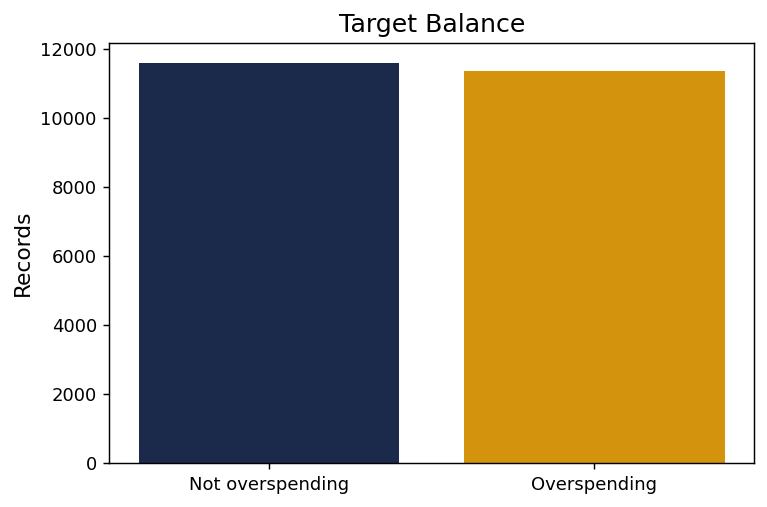

**Overspending rate by age group**

,age_group,overspending_rate_pct
0,young,0.0000
1,middle_aged,55.5600
2,old,45.6900


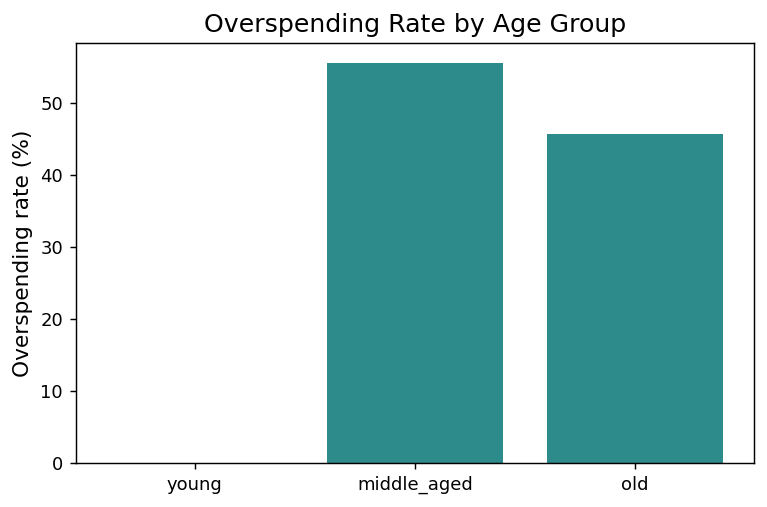

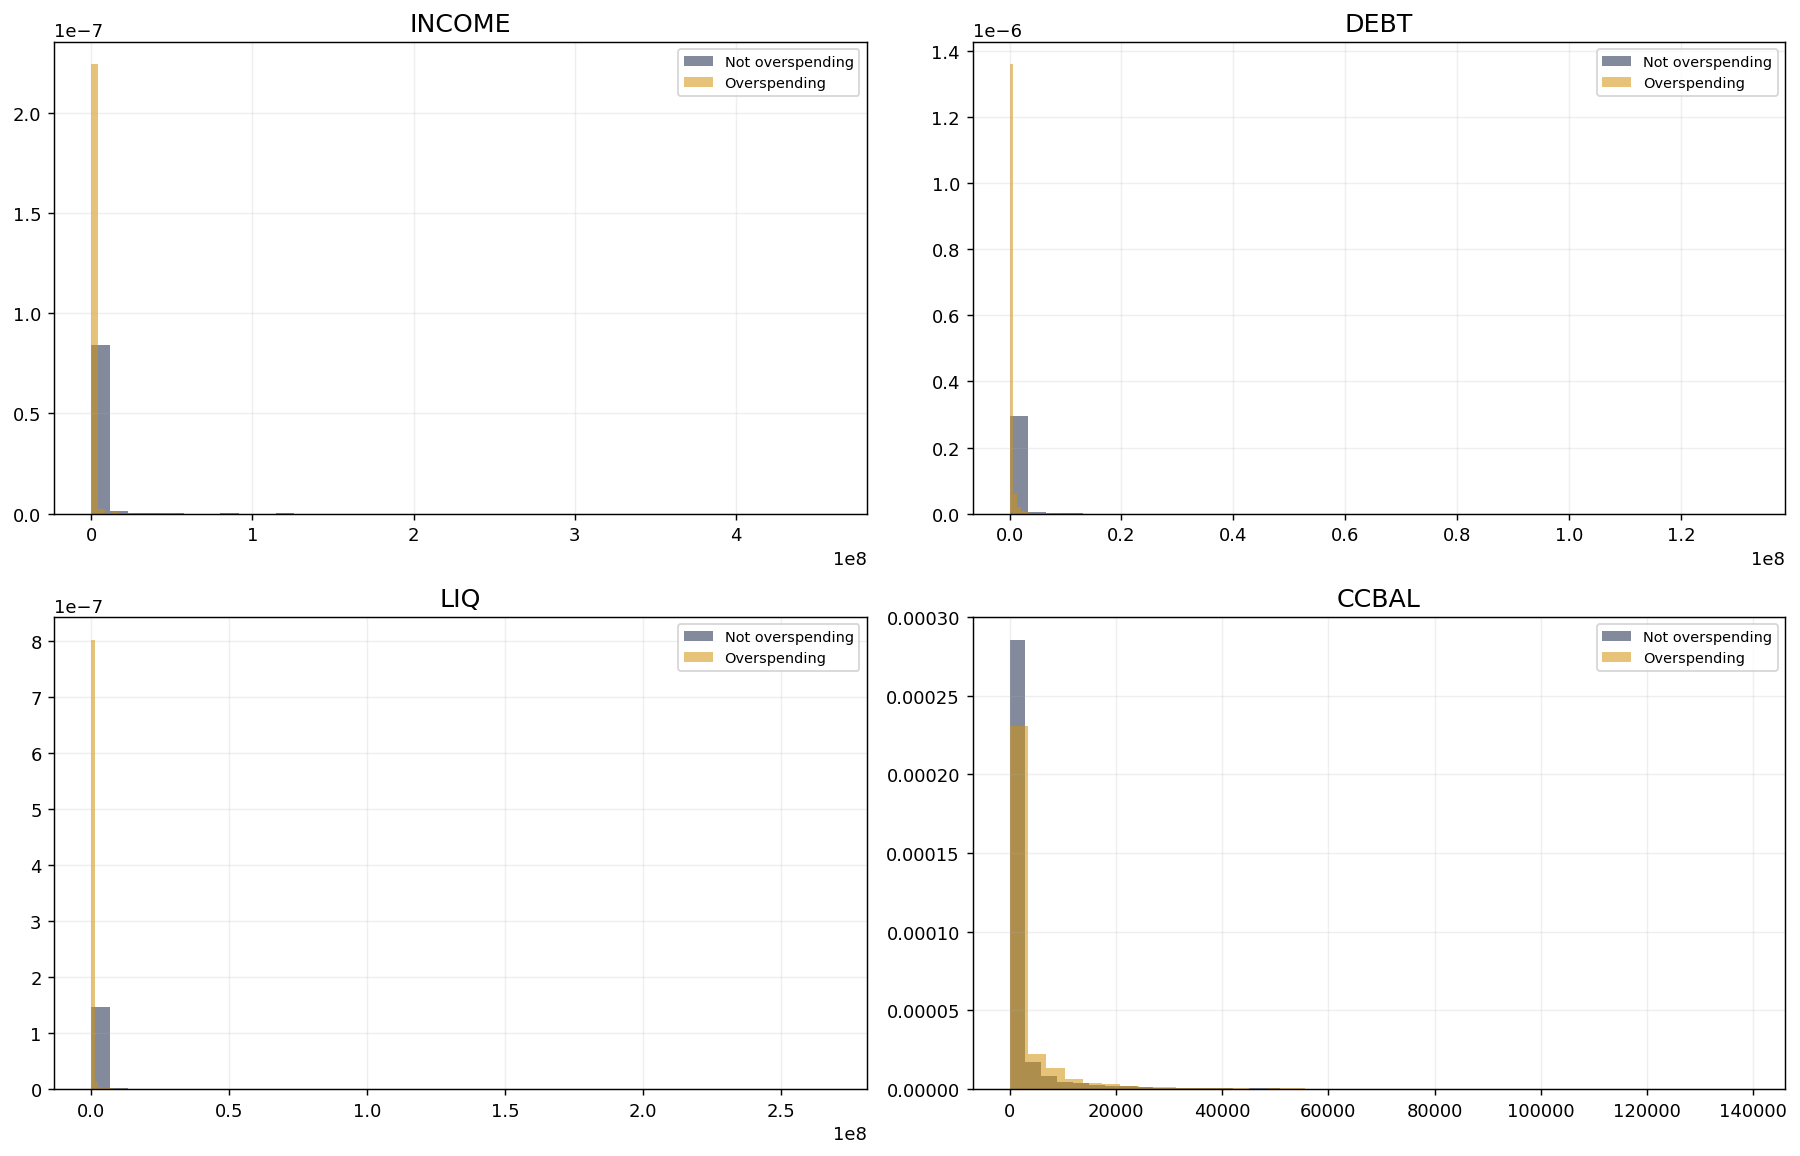

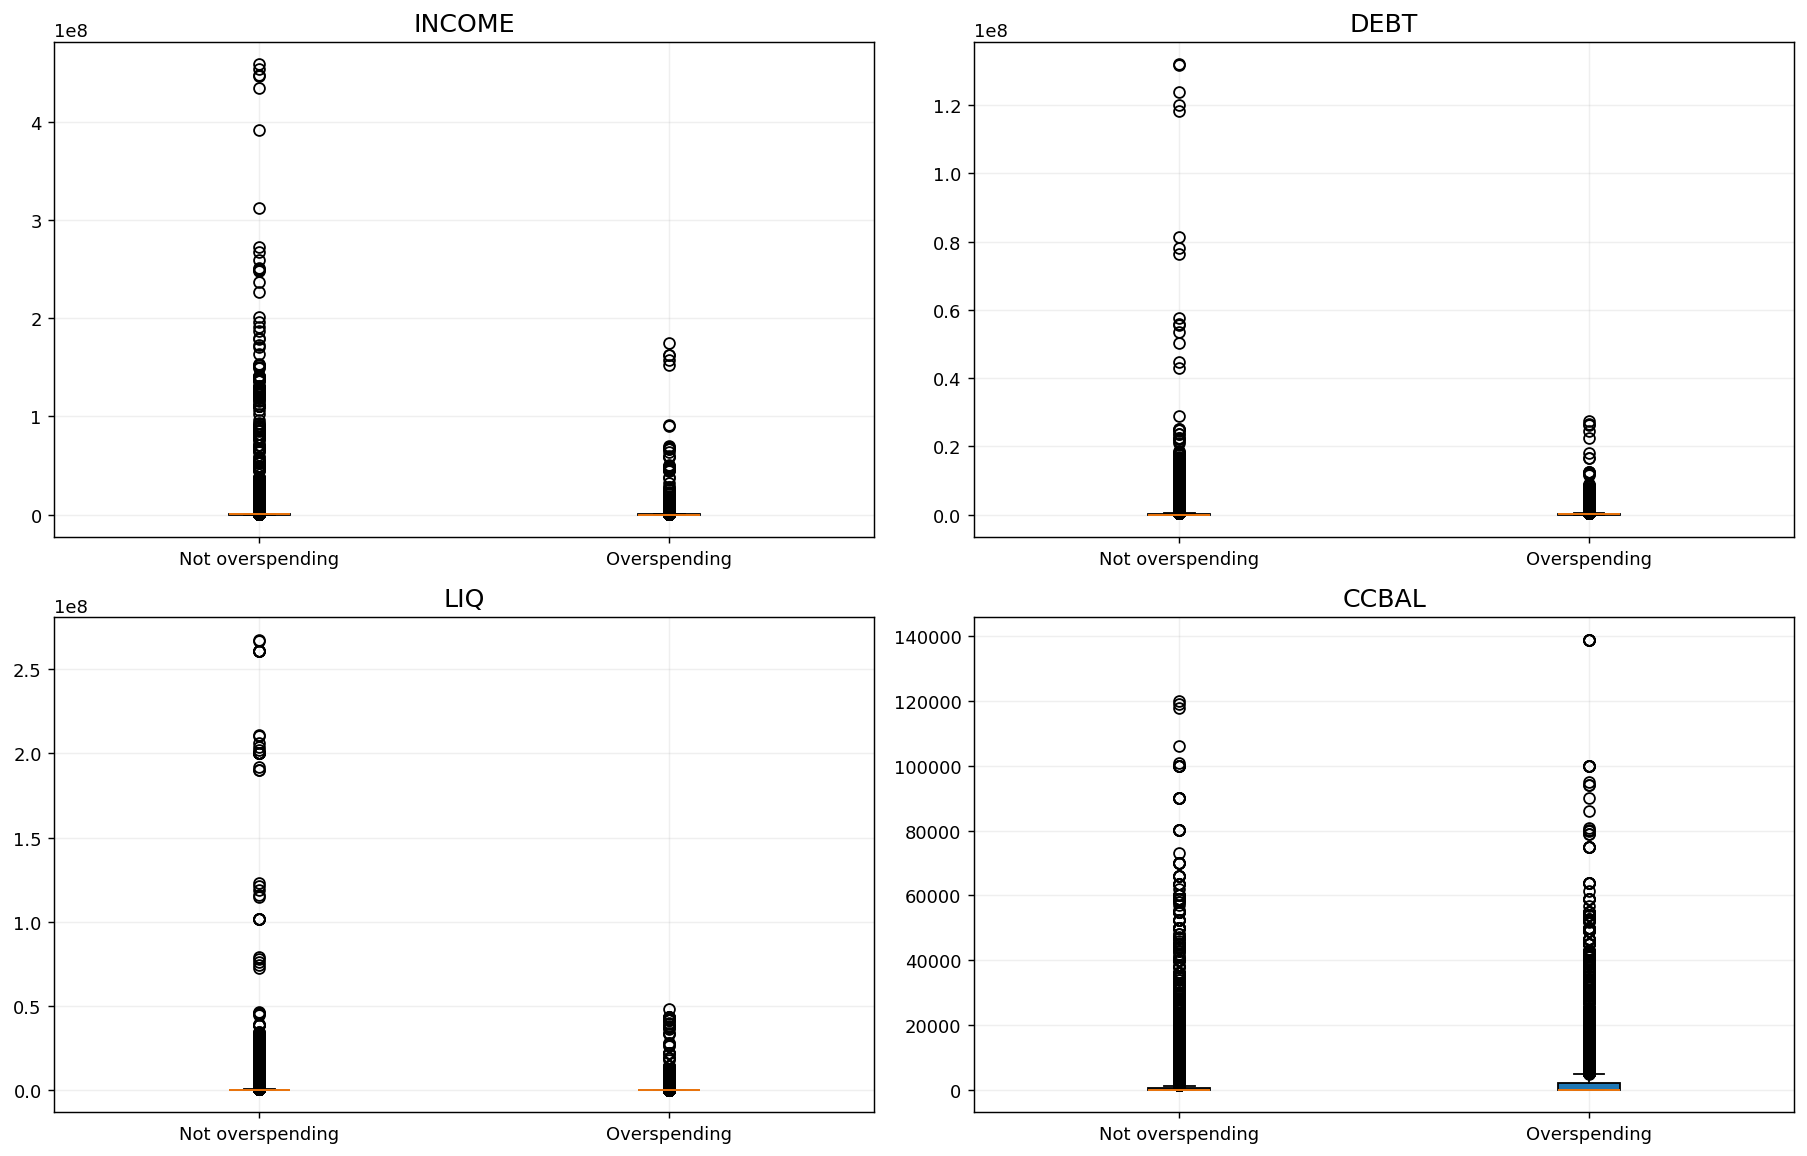

> **Why we proceed:** The early pattern check suggests that some variables already separate overspending and non-overspending households, especially DEBT, INCOME, LIQ. That is enough signal to justify moving next into candidate feature design and leakage-safe model comparison rather than collecting more raw descriptive output first.

In [15]:
exploration_features = [feature for feature in ["INCOME", "DEBT", "LIQ", "CCBAL", "CONSPAY", "FOODHOME", "FOODAWAY", "AGE"] if feature in theory_seed_available]

group_medians = df.groupby("target")[exploration_features].median().T.rename(columns={0: "median_not_overspending", 1: "median_overspending"})
group_medians["difference_overspending_minus_not"] = group_medians["median_overspending"] - group_medians["median_not_overspending"]
group_medians = group_medians.sort_values("difference_overspending_minus_not", key=lambda s: s.abs(), ascending=False)

display_heading("Median feature values by target")
display(group_medians.round(4))

plt.figure(figsize=(6, 4))
target_counts = df["target"].value_counts().sort_index()
plt.bar([0, 1], [target_counts.get(0, 0), target_counts.get(1, 0)], color=[COLORS["navy"], COLORS["gold"]])
plt.xticks([0, 1], ["Not overspending", "Overspending"])
plt.ylabel("Records")
plt.title("Target Balance")
plt.tight_layout()
plt.show()

if "age_group" in df.columns:
    age_rates = df.groupby("age_group", observed=False)["target"].mean().mul(100).reset_index(name="overspending_rate_pct")
    display_heading("Overspending rate by age group")
    display(age_rates.round(2))
    plt.figure(figsize=(6, 4))
    plt.bar(age_rates["age_group"].astype(str), age_rates["overspending_rate_pct"], color=COLORS["teal"])
    plt.ylabel("Overspending rate (%)")
    plt.title("Overspending Rate by Age Group")
    plt.tight_layout()
    plt.show()

plot_grouped_histograms(df, exploration_features[:4])
plt.show()

plot_grouped_boxplots(df, exploration_features[:4])
plt.show()

top_shift_features = group_medians.head(3).index.tolist()
show_note(
    f"The early pattern check suggests that some variables already separate overspending and non-overspending households, especially {', '.join(top_shift_features)}. That is enough signal to justify moving next into candidate feature design and leakage-safe model comparison rather than collecting more raw descriptive output first."
)


## Designing Candidate Features

The model in this project needs to be both useful and explainable. That means we should not blindly include every screened variable. Instead, we combine the theory-driven seed with a small number of screened additions and then engineer features that make financial sense.

In [16]:
df_features = add_engineered_features(df.copy())

ratio_features = ["DTI", "PAYMENT_TO_INC", "CC_TO_INC"]
interaction_features = ["FOODHOME_X_AGE", "DTI_X_AGE", "LIQ_SQUEEZE", "FOOD_DISCRETIONARY"]

theory_plus_screened = theory_seed_available + screened_signal_additions
theory_plus_screened = list(dict.fromkeys([feature for feature in theory_plus_screened if feature in df_features.columns]))
explainability_ready_features = theory_plus_screened + [feature for feature in ratio_features + interaction_features if feature in df_features.columns]
explainability_ready_features = list(dict.fromkeys(explainability_ready_features))

feature_roles = []
for feature in theory_seed_available:
    feature_roles.append({"feature": feature, "role": "theory_seed", "available": feature in df_features.columns})
for feature in screened_signal_additions:
    feature_roles.append({"feature": feature, "role": "screened_addition", "available": feature in df_features.columns})
for feature in ratio_features:
    feature_roles.append({"feature": feature, "role": "engineered_ratio", "available": feature in df_features.columns})
for feature in interaction_features:
    feature_roles.append({"feature": feature, "role": "engineered_interaction", "available": feature in df_features.columns})

feature_role_df = pd.DataFrame(feature_roles)
display_heading("Candidate features and roles")
display(feature_role_df)

candidate_feature_sets = {
    "Theory-driven seed": theory_seed_available,
    "Theory + screened additions": theory_plus_screened,
    "Explainability-ready candidate set": explainability_ready_features,
}

feature_set_summary = []
for name, features in candidate_feature_sets.items():
    feature_set_summary.append({
        "feature_set": name,
        "n_features": len(features),
        "features": ", ".join(features),
    })

feature_set_summary_df = pd.DataFrame(feature_set_summary)
display_heading("Candidate feature sets")
display(feature_set_summary_df)

selected_feature_set_name = "Explainability-ready candidate set"
selected_feature_cols = candidate_feature_sets[selected_feature_set_name]

display_heading("Selected feature set for the first modeling pass")
display(pd.DataFrame({"feature": selected_feature_cols}))

show_note(
    f"We will start with the '{selected_feature_set_name}' because it combines theory-driven variables, screened additions from the wider pool, and financially meaningful engineered features. That makes the first modeling pass more defensible than either a purely hand-picked list or a brute-force all-columns approach."
)


**Candidate features and roles**

,feature,role,available
0,INCOME,theory_seed,True
1,DEBT,theory_seed,True
2,LIQ,theory_seed,True
3,ASSET,theory_seed,True
4,CCBAL,theory_seed,True
5,CONSPAY,theory_seed,True
6,FOODHOME,theory_seed,True
7,FOODAWAY,theory_seed,True
8,AGE,theory_seed,True
9,EDUC,theory_seed,True


**Candidate feature sets**

,feature_set,n_features,features
0,Theory-driven seed,13,"INCOME, DEBT, LIQ, ASSET, CCBAL, CONSPAY, FOOD..."
1,Theory + screened additions,23,"INCOME, DEBT, LIQ, ASSET, CCBAL, CONSPAY, FOOD..."
2,Explainability-ready candidate set,30,"INCOME, DEBT, LIQ, ASSET, CCBAL, CONSPAY, FOOD..."


**Selected feature set for the first modeling pass**

,feature
0,INCOME
1,DEBT
2,LIQ
3,ASSET
4,CCBAL
5,CONSPAY
6,FOODHOME
7,FOODAWAY
8,AGE
9,EDUC


> **Why we proceed:** We will start with the 'Explainability-ready candidate set' because it combines theory-driven variables, screened additions from the wider pool, and financially meaningful engineered features. That makes the first modeling pass more defensible than either a purely hand-picked list or a brute-force all-columns approach.

## Building the Modeling Dataset

Now we turn the selected candidate features into a clean modeling table. The point here is to create one canonical dataset that later sections can reuse for model comparison, feature importance, SHAP, and downstream explanation outputs.

In [17]:
modeling_df_raw = df_features.copy()

pre_clean_missing = (
    modeling_df_raw[selected_feature_cols]
    .isna()
    .sum()
    .rename("missing_count_before_cleaning")
    .reset_index()
    .rename(columns={"index": "feature"})
)
pre_clean_missing = pre_clean_missing[pre_clean_missing["missing_count_before_cleaning"] > 0].sort_values("missing_count_before_cleaning", ascending=False)

modeling_df, prep_log_df = clean_modeling_frame(modeling_df_raw, selected_feature_cols)

modeling_columns = ["household_id", "target"] + selected_feature_cols
final_modeling_df = modeling_df[modeling_columns].copy()

display_heading("Missingness before cleaning")
display(pre_clean_missing if not pre_clean_missing.empty else pd.DataFrame({"note": ["No missing values in selected features before cleaning."]}))

display_heading("Preparation log")
display(prep_log_df if not prep_log_df.empty else pd.DataFrame({"note": ["No cleaning operations were needed."]}))

display_heading("Final modeling dataset preview")
display(final_modeling_df.head())

print(f"Modeling rows: {len(final_modeling_df):,}")
print(f"Modeling features: {len(selected_feature_cols):,}")

show_note(
    "We now have one clean, reusable modeling table. That matters because the next steps should compare models on exactly the same inputs rather than letting preprocessing drift across sections."
)


**Missingness before cleaning**

,feature,missing_count_before_cleaning
24,PAYMENT_TO_INC,197
25,CC_TO_INC,197


**Preparation log**

,feature,step,count,value
0,PAYMENT_TO_INC,median_imputation,197,0.0000
1,CC_TO_INC,median_imputation,197,0.0000
2,INCOME,upper_clip_p99,229,"29,076,528.0560"
3,DEBT,upper_clip_p99,230,"5,628,900.0000"
4,LIQ,upper_clip_p99,227,"12,035,000.0000"
5,ASSET,upper_clip_p99,230,"469,155,300.0000"
6,CCBAL,upper_clip_p99,207,"40,000.0000"
7,CONSPAY,upper_clip_p99,230,"6,078.0000"
8,FOODHOME,upper_clip_p99,194,"36,000.0000"
9,FOODAWAY,upper_clip_p99,229,"40,560.0000"


**Final modeling dataset preview**

,household_id,target,INCOME,DEBT,LIQ,ASSET,CCBAL,CONSPAY,FOODHOME,FOODAWAY,AGE,EDUC,FAMSTRUCT,HOUSECL,FINLIT,INSTALL,NETWORTH,INTDIVINC,EMERGSAV,CHECKING,NORMINC,REVPAY,KIDS,LATE,RENT,DTI,PAYMENT_TO_INC,CC_TO_INC,FOODHOME_X_AGE,DTI_X_AGE,LIQ_SQUEEZE,FOOD_DISCRETIONARY
0,1,0,"38,804.7345","195,000.0000",13100,"957,100.0000",0,0.0000,600,0,70,9,1,1,1,0,"762,100.0000",54.0456,1,6700,"38,804.7345",0.0000,2,0,0.0000,5.0252,0.0000,0.0000,42000,351.7612,0.0000,0.0000
1,1,0,"38,264.2786","213,000.0000",7300,"1,067,300.0000",0,0.0000,600,0,70,9,1,1,1,0,"854,300.0000",54.0456,1,4200,"38,264.2786",0.0000,2,0,0.0000,5.5665,0.0000,0.0000,42000,389.6585,0.0000,0.0000
2,1,0,"36,102.4549","279,000.0000",5200,"957,200.0000",0,0.0000,600,0,70,9,1,1,1,0,"678,200.0000",54.0456,1,3200,"36,102.4549",0.0000,2,0,0.0000,7.7280,0.0000,0.0000,42000,540.9604,0.0000,0.0000
3,1,0,"33,508.2665","549,000.0000",51600,"828,600.0000",0,0.0000,600,0,70,9,1,1,1,0,"279,600.0000",54.0456,1,2600,"33,508.2665",0.0000,2,0,0.0000,10.0000,0.0000,0.0000,42000,620.0000,0.0000,0.0000
4,1,0,"35,561.9990","223,000.0000",7600,"825,600.0000",0,0.0000,600,0,70,9,1,1,1,0,"602,600.0000",54.0456,1,1800,"35,561.9990",0.0000,2,0,0.0000,6.2707,0.0000,0.0000,42000,438.9517,0.0000,0.0000


Modeling rows: 22,975
Modeling features: 30


> **Why we proceed:** We now have one clean, reusable modeling table. That matters because the next steps should compare models on exactly the same inputs rather than letting preprocessing drift across sections.

## Creating a Leakage-Safe Evaluation Plan

Because each household appears multiple times through the SCF implicates, we cannot split rows at random. This section documents the grouped train/test split that we already created during feature screening and reuses it for model evaluation.

In [18]:
X = final_modeling_df[selected_feature_cols]
y = final_modeling_df["target"]
groups = final_modeling_df["household_id"]

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

evaluation_summary = pd.DataFrame([
    {
        "split": "train",
        "records": len(X_train),
        "unique_households": groups_train.nunique(),
        "positive_rate": y_train.mean(),
    },
    {
        "split": "test",
        "records": len(X_test),
        "unique_households": groups_test.nunique(),
        "positive_rate": y_test.mean(),
    },
])

display_heading("Evaluation split summary")
display(evaluation_summary.round(4))

household_overlap = len(set(groups_train).intersection(set(groups_test)))
print(f"Household overlap between train and test: {household_overlap}")

show_note(
    "The grouped split prevents the same household from appearing in both train and test, which protects us from leakage. Reusing the same split for screening and model comparison also keeps the workflow internally consistent."
)


**Evaluation split summary**

,split,records,unique_households,positive_rate
0,train,18380,3676,0.4968
1,test,4595,919,0.4868


Household overlap between train and test: 0


> **Why we proceed:** The grouped split prevents the same household from appearing in both train and test, which protects us from leakage. Reusing the same split for screening and model comparison also keeps the workflow internally consistent.

## Comparing Baseline Models

This section compares a small set of strong baseline models on the same grouped evaluation design. The goal here is not yet to over-tune, but to identify which modeling family looks promising enough to carry forward into refinement, feature importance, SHAP, and explanation work.

**Baseline model performance**

,cv_auc_mean,cv_auc_std,test_auc,accuracy,f1,brier
model,,,,,,
Logistic Regression,0.6210,0.0145,0.6197,0.5785,0.5901,0.2399
Random Forest,0.5989,0.0097,0.6125,0.5785,0.5874,0.2439


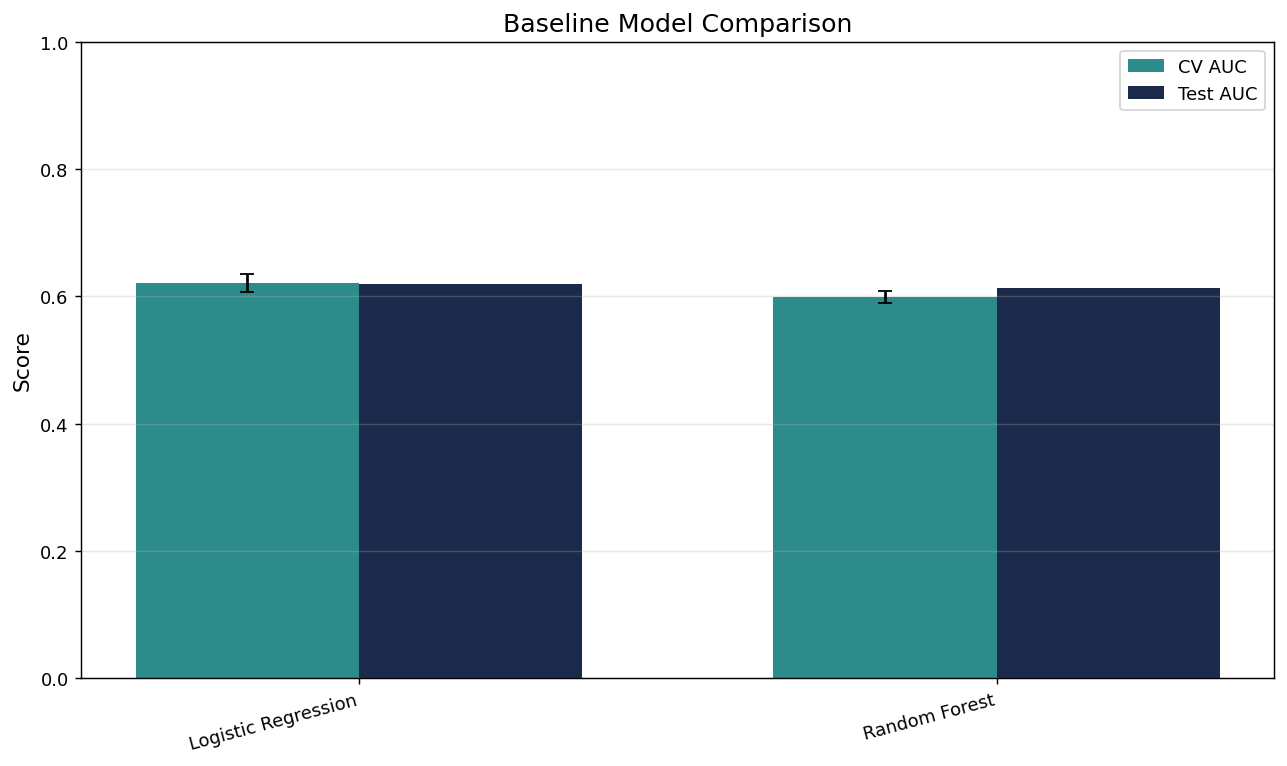

Current leading baseline model: Logistic Regression


> **Why we proceed:** Logistic Regression is the strongest baseline by grouped CV AUC (0.621). That makes it the current front-runner, but the next stage should still check refinement, calibration, and feature importance before we finalize the model that will feed SHAP and the explanation study.

In [19]:
baseline_performance_df, fitted_baseline_models = evaluate_model_suite(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    groups_train=groups_train,
)

display_heading("Baseline model performance")
display(baseline_performance_df.round(4))

plot_model_performance(baseline_performance_df)
plt.show()

best_baseline_model_name = baseline_performance_df.index[0]
print(f"Current leading baseline model: {best_baseline_model_name}")

show_note(summarize_baseline_results(baseline_performance_df))


## Refining the Best Model

The strongest baseline model is only a starting point. This section performs a small, defensible tuning pass so we can improve the leading model without turning the notebook into a large hyperparameter search.

In [20]:
best_baseline_model_name = baseline_performance_df.index[0]

def build_refinement_estimator(model_name: str, params: dict):
    if model_name == "Logistic Regression":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                C=params["C"],
                penalty="l2",
                class_weight=params["class_weight"],
                max_iter=1000,
                random_state=RANDOM_STATE,
            )),
        ])
    if model_name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=params["n_estimators"],
            min_samples_leaf=params["min_samples_leaf"],
            max_depth=params["max_depth"],
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    if model_name == "XGBoost":
        scale_pos_weight = (len(y_train) - int(y_train.sum())) / max(int(y_train.sum()), 1)
        return xgb.XGBClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            scale_pos_weight=scale_pos_weight,
        )
    raise ValueError(f"Unsupported model: {model_name}")

if best_baseline_model_name == "Logistic Regression":
    refinement_grid = [
        {"C": 0.25, "class_weight": "balanced"},
        {"C": 0.50, "class_weight": "balanced"},
        {"C": 1.00, "class_weight": "balanced"},
        {"C": 2.00, "class_weight": "balanced"},
    ]
elif best_baseline_model_name == "Random Forest":
    refinement_grid = [
        {"n_estimators": 300, "min_samples_leaf": 5, "max_depth": None},
        {"n_estimators": 400, "min_samples_leaf": 5, "max_depth": None},
        {"n_estimators": 300, "min_samples_leaf": 3, "max_depth": 10},
        {"n_estimators": 500, "min_samples_leaf": 5, "max_depth": 12},
    ]
else:
    refinement_grid = [
        {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05},
        {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.05},
        {"n_estimators": 400, "max_depth": 4, "learning_rate": 0.03},
    ]

refinement_rows = []
cv_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for params in refinement_grid:
    estimator = build_refinement_estimator(best_baseline_model_name, params)
    cv_scores = cross_val_score(
        clone(estimator),
        X_train,
        y_train,
        groups=groups_train,
        cv=cv_splitter,
        scoring="roc_auc",
        n_jobs=1,
    )
    fitted_estimator = clone(estimator)
    fitted_estimator.fit(X_train, y_train)
    y_prob = fitted_estimator.predict_proba(X_test)[:, 1]
    y_pred = fitted_estimator.predict(X_test)
    refinement_rows.append({
        **params,
        "cv_auc_mean": float(np.mean(cv_scores)),
        "cv_auc_std": float(np.std(cv_scores)),
        "test_auc": float(roc_auc_score(y_test, y_prob)),
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "f1": float(f1_score(y_test, y_pred)),
        "brier": float(brier_score_loss(y_test, y_prob)),
    })

refinement_results_df = pd.DataFrame(refinement_rows).sort_values(["cv_auc_mean", "test_auc"], ascending=[False, False]).reset_index(drop=True)
best_refined_params = refinement_results_df.iloc[0].to_dict()
refined_best_model = build_refinement_estimator(best_baseline_model_name, best_refined_params)
refined_best_model.fit(X_train, y_train)
refined_test_prob = refined_best_model.predict_proba(X_test)[:, 1]
refined_test_pred = refined_best_model.predict(X_test)

display_heading("Refinement results")
display(refinement_results_df.round(4))

refined_model_summary = pd.DataFrame([
    {
        "model_family": best_baseline_model_name,
        "cv_auc_mean": best_refined_params["cv_auc_mean"],
        "test_auc": roc_auc_score(y_test, refined_test_prob),
        "accuracy": accuracy_score(y_test, refined_test_pred),
        "f1": f1_score(y_test, refined_test_pred),
        "brier": brier_score_loss(y_test, refined_test_prob),
    }
])
display_heading("Selected refined model")
display(refined_model_summary.round(4))

show_note(
    f"We refined the leading baseline within a small, explainable search space and kept the best version of {best_baseline_model_name}. This is enough tuning to improve the model responsibly without drifting into a black-box optimization process that would be harder to justify in the later explanation study."
)


**Refinement results**

,C,class_weight,cv_auc_mean,cv_auc_std,test_auc,accuracy,f1,brier
0,0.2500,balanced,0.6211,0.0145,0.6197,0.5795,0.5915,0.2399
1,0.5000,balanced,0.6210,0.0145,0.6197,0.5782,0.5899,0.2399
2,1.0000,balanced,0.6210,0.0145,0.6197,0.5785,0.5901,0.2399
3,2.0000,balanced,0.6210,0.0145,0.6196,0.5782,0.5899,0.2399


**Selected refined model**

,model_family,cv_auc_mean,test_auc,accuracy,f1,brier
0,Logistic Regression,0.6211,0.6197,0.5795,0.5915,0.2399


> **Why we proceed:** We refined the leading baseline within a small, explainable search space and kept the best version of Logistic Regression. This is enough tuning to improve the model responsibly without drifting into a black-box optimization process that would be harder to justify in the later explanation study.

## Checking Calibration and Reliability

Because later users will see explanations tied to model outputs, it is not enough for the model to rank households well. Its predicted probabilities also need to be reasonably trustworthy.

**Calibration summary**

,version,auc,brier
0,uncalibrated,0.6197,0.2399
1,isotonic_calibrated,0.6164,0.2419


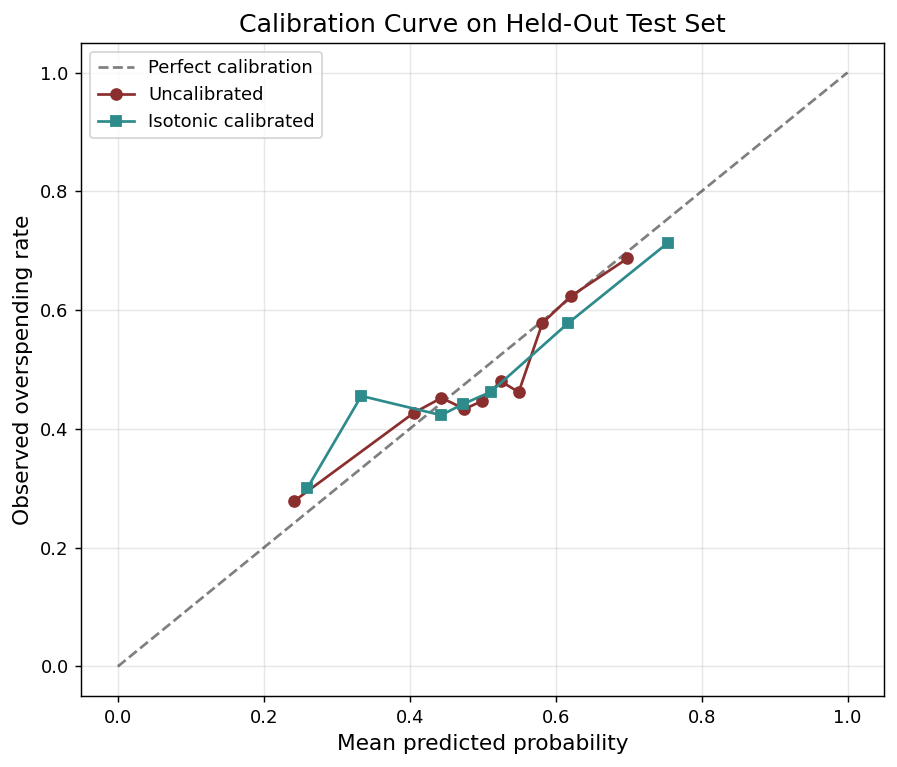

> **Why we proceed:** This calibration check tells us whether the model probabilities are trustworthy enough to support later user-facing explanations. We keep the calibrated version only if it improves or at least preserves reliability, because misleading probabilities would weaken both the UI and the survey study.

In [21]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

calibration_splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE + 1)
model_train_idx, calibration_idx = next(calibration_splitter.split(X_train, y_train, groups=groups_train))

X_model_train = X_train.iloc[model_train_idx]
y_model_train = y_train.iloc[model_train_idx]
X_calibration = X_train.iloc[calibration_idx]
y_calibration = y_train.iloc[calibration_idx]

base_for_calibration = build_refinement_estimator(best_baseline_model_name, best_refined_params)
base_for_calibration.fit(X_model_train, y_model_train)

calibrated_model = CalibratedClassifierCV(base_for_calibration, method="isotonic", cv="prefit")
calibrated_model.fit(X_calibration, y_calibration)

raw_prob_test = refined_best_model.predict_proba(X_test)[:, 1]
calibrated_prob_test = calibrated_model.predict_proba(X_test)[:, 1]

calibration_summary_df = pd.DataFrame([
    {
        "version": "uncalibrated",
        "auc": roc_auc_score(y_test, raw_prob_test),
        "brier": brier_score_loss(y_test, raw_prob_test),
    },
    {
        "version": "isotonic_calibrated",
        "auc": roc_auc_score(y_test, calibrated_prob_test),
        "brier": brier_score_loss(y_test, calibrated_prob_test),
    },
])

display_heading("Calibration summary")
display(calibration_summary_df.round(4))

prob_true_raw, prob_pred_raw = calibration_curve(y_test, raw_prob_test, n_bins=10, strategy="quantile")
prob_true_cal, prob_pred_cal = calibration_curve(y_test, calibrated_prob_test, n_bins=10, strategy="quantile")

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="black", alpha=0.5, label="Perfect calibration")
plt.plot(prob_pred_raw, prob_true_raw, marker="o", color=COLORS["red"], label="Uncalibrated")
plt.plot(prob_pred_cal, prob_true_cal, marker="s", color=COLORS["teal"], label="Isotonic calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed overspending rate")
plt.title("Calibration Curve on Held-Out Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

final_prediction_model = calibrated_model if calibration_summary_df.loc[1, "brier"] <= calibration_summary_df.loc[0, "brier"] else refined_best_model
final_prediction_prob_test = calibrated_prob_test if final_prediction_model is calibrated_model else raw_prob_test

show_note(
    "This calibration check tells us whether the model probabilities are trustworthy enough to support later user-facing explanations. We keep the calibrated version only if it improves or at least preserves reliability, because misleading probabilities would weaken both the UI and the survey study."
)


## Identifying the Most Predictive Features

This section answers the core prediction question directly: which features matter most for predicting `EXPENSHILO` in the refined model? We use permutation importance because it measures how much predictive performance falls when each feature is disrupted.

**Permutation importance**

,feature,importance_mean,importance_std
0,NORMINC,0.0257,0.0033
1,FOODHOME,0.0245,0.0040
2,DTI,0.0181,0.0022
3,EMERGSAV,0.0116,0.0024
4,LATE,0.0098,0.0024
5,RENT,0.0086,0.0016
6,REVPAY,0.0081,0.0022
7,FOODAWAY,0.0076,0.0021
8,DEBT,0.0054,0.0023
9,DTI_X_AGE,0.0052,0.0025


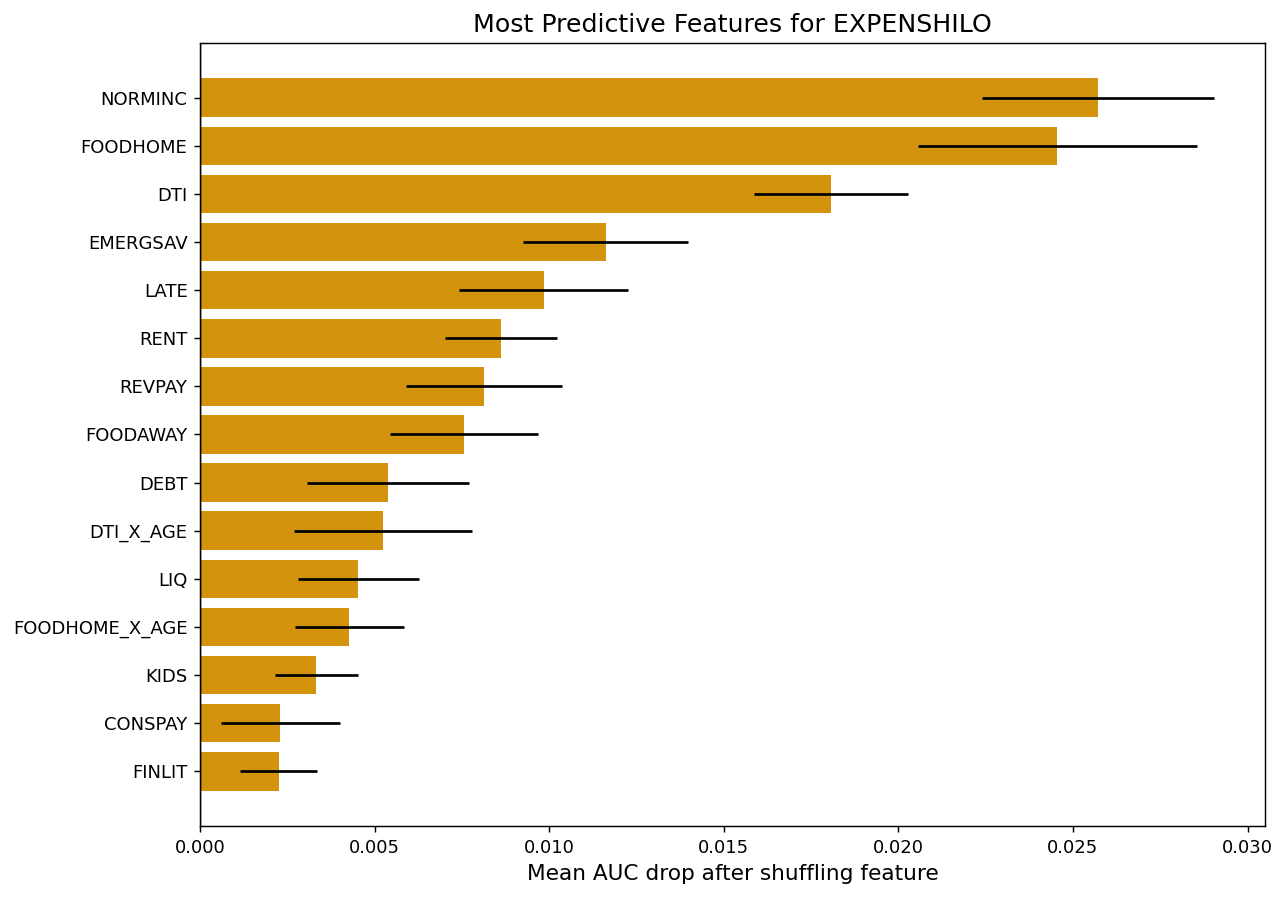

> **Why we proceed:** Permutation importance identifies the features that actually help the refined model predict overspending, not just the ones that look correlated in isolation. These rankings will anchor the later SHAP and plain-language explanation stages.

In [22]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    refined_best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
    n_jobs=1,
)

predictive_feature_importance_df = pd.DataFrame({
    "feature": selected_feature_cols,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

display_heading("Permutation importance")
display(predictive_feature_importance_df.round(4))

top_plot_df = predictive_feature_importance_df.head(15).sort_values("importance_mean")
plt.figure(figsize=(10, 7))
plt.barh(top_plot_df["feature"], top_plot_df["importance_mean"], xerr=top_plot_df["importance_std"], color=COLORS["gold"])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Mean AUC drop after shuffling feature")
plt.title("Most Predictive Features for EXPENSHILO")
plt.tight_layout()
plt.show()

top_predictive_features = predictive_feature_importance_df.head(10)["feature"].tolist()
show_note(
    f"Permutation importance identifies the features that actually help the refined model predict overspending, not just the ones that look correlated in isolation. These rankings will anchor the later SHAP and plain-language explanation stages."
)


## Generating SHAP-Based Explanations

Now that the model has been refined and the main predictive features are known, we generate SHAP-based explanations. This is the first direct bridge from model development into the explainability stage of the study.

**Global SHAP importance**

,feature,mean_abs_shap
0,FOODHOME,0.1966
1,EMERGSAV,0.1254
2,DTI,0.1251
3,DTI_X_AGE,0.1099
4,DEBT,0.1066
5,NORMINC,0.1057
6,LATE,0.0785
7,FOODAWAY,0.0728
8,CONSPAY,0.0688
9,HOUSECL,0.0599


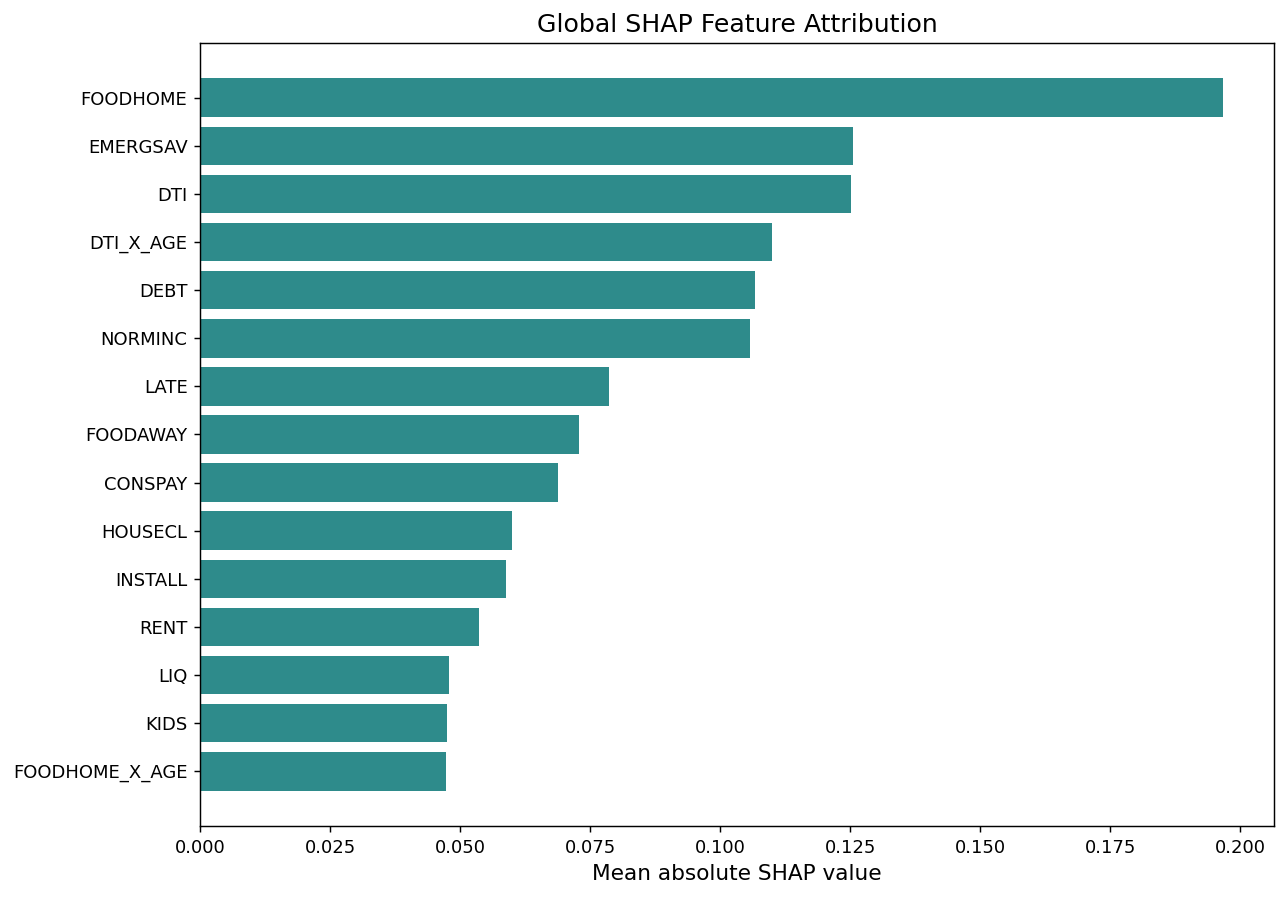

**Local SHAP explanation for one high-risk example**

,feature,feature_value,shap_value,abs_shap
0,LATE,1.0000,0.2146,0.2146
1,FOODHOME,"13,520.0000",0.1808,0.1808
2,EMERGSAV,0.0000,0.1318,0.1318
3,NORMINC,"32,427.3547",0.1234,0.1234
4,HOUSECL,2.0000,0.0990,0.0990
5,DEBT,"50,000.0000",0.0867,0.0867
6,CONSPAY,0.0000,-0.0748,0.0748
7,EDUC,4.0000,0.0585,0.0585
8,INSTALL,"50,000.0000",0.0562,0.0562
9,LIQ,"1,505.0000",0.0535,0.0535


> **Why we proceed:** SHAP gives us the bridge from prediction into explanation. We keep both a global view of which features matter overall and a local view of why one household receives a specific risk assessment, because the later user study will depend on both types of explanation.

In [23]:
try:
    import shap
    HAS_SHAP = True
except ModuleNotFoundError:
    shap = None
    HAS_SHAP = False

global_shap_importance_df = None
local_shap_explanation_df = None
sample_explanation_row = 0

if HAS_SHAP:
    explanation_sample_n = min(300, len(X_test))
    background_n = min(500, len(X_train))
    X_explain = X_test.iloc[:explanation_sample_n].copy()
    X_background = X_train.iloc[:background_n].copy()

    if best_baseline_model_name == "Logistic Regression":
        scaler = refined_best_model.named_steps["scaler"]
        linear_model = refined_best_model.named_steps["model"]
        X_background_scaled = pd.DataFrame(scaler.transform(X_background), columns=selected_feature_cols)
        X_explain_scaled = pd.DataFrame(scaler.transform(X_explain), columns=selected_feature_cols)
        explainer = shap.LinearExplainer(linear_model, X_background_scaled)
        shap_values = explainer(X_explain_scaled)
        shap_matrix = np.array(shap_values.values)
    else:
        explainer = shap.TreeExplainer(refined_best_model)
        shap_values = explainer(X_explain)
        shap_matrix = np.array(shap_values.values)
        if shap_matrix.ndim == 3:
            shap_matrix = shap_matrix[:, :, 1]

    global_shap_importance_df = pd.DataFrame({
        "feature": selected_feature_cols,
        "mean_abs_shap": np.abs(shap_matrix).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    sample_explanation_row = int(np.argmax(final_prediction_prob_test[:explanation_sample_n]))
    local_shap_explanation_df = pd.DataFrame({
        "feature": selected_feature_cols,
        "feature_value": X_explain.iloc[sample_explanation_row].values,
        "shap_value": shap_matrix[sample_explanation_row],
    })
    local_shap_explanation_df["abs_shap"] = local_shap_explanation_df["shap_value"].abs()
    local_shap_explanation_df = local_shap_explanation_df.sort_values("abs_shap", ascending=False).reset_index(drop=True)

    display_heading("Global SHAP importance")
    display(global_shap_importance_df.head(15).round(4))

    shap_plot_df = global_shap_importance_df.head(15).sort_values("mean_abs_shap")
    plt.figure(figsize=(10, 7))
    plt.barh(shap_plot_df["feature"], shap_plot_df["mean_abs_shap"], color=COLORS["teal"])
    plt.xlabel("Mean absolute SHAP value")
    plt.title("Global SHAP Feature Attribution")
    plt.tight_layout()
    plt.show()

    display_heading("Local SHAP explanation for one high-risk example")
    display(local_shap_explanation_df.head(10).round(4))
else:
    print("SHAP is not available in this environment, so this section is a placeholder until the package is installed.")

show_note(
    "SHAP gives us the bridge from prediction into explanation. We keep both a global view of which features matter overall and a local view of why one household receives a specific risk assessment, because the later user study will depend on both types of explanation."
)
